In [2]:
from preload import *
import statsmodels.formula.api as smf

color_f=['#2D3074','#234755','#33674C','#6E99C1','#3D74B5','#429199','#E6DDD5',
         '#E8843A',
         '#DB4E5A','#9A2A2E']
FieldList=['Mathematics', 
 'Earth & Environmental Science','Social Sciences',
 'Physics','Chemistry','Materials Science', 
 'Engineering','Computer science',
'Biology','Medicine']
NameList=['Mathematics', 
 'GeoScience','Social Sciences',
'Physics','Chemistry','Materials Science', 'Engineering', 'Computer science',
'Biology','Medicine']
FN=dict(zip(FieldList,NameList))
FC=dict(zip(FieldList
            ,color_f))
linewidth=3
ticklabel_fontsize=25
label_fontsize=25
title_fontsize=22
title_x_postion=-.18
ylabel_y_postion=-1
labelpad=16
plt.rcParams['font.family']=['Helvetica']

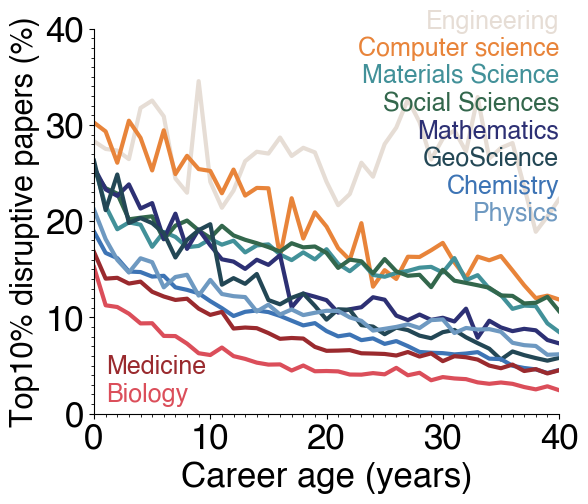

In [4]:
fig = plt.figure(figsize=(6,5),facecolor='white')

k=0
tmp={}
with open('./FigureData/FigureData2_Dict_1960_1970_40.txt','r')as f:
    for line in f:
        field,y = line.strip().split('\t')
        y=json.loads(y)
        y=np.array(y)
        tmp[field]=y
        

for field in ['Engineering','Computer science','Materials Science', 'Social Sciences','Mathematics',
 'Earth & Environmental Science', 'Chemistry', 'Physics','Medicine','Biology',
]:
    x=range(41)
    y=tmp[field]
    line_kws={'lw':2.5}
    plt.plot(x,y[:,0],color=FC[field],lw=linewidth,label=field) 
    if k<=7:
        plt.text(40,.4-k/35,FN[field],fontsize=18,color =FC[field],ha='right')
    else:
        plt.text(1,.07-(k-7)/35,FN[field],fontsize=18,color =FC[field],ha='left')
    k+=1
#plt.ylim(0.42,0.52)
plt.xlim(0,40)
plt.ylim(0,0.4)
ax= plt.gca()
ax.tick_params(axis='both', which='major', labelsize=ticklabel_fontsize)
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Career age (years)',fontsize=label_fontsize)
plt.ylabel('Top10% disruptive papers (%)',fontsize=label_fontsize-3)
# plt.title('Disruption Declines with Career Age\n',
#           fontsize=title_fontsize,fontweight='heavy',
#           horizontalalignment='center')
plt.yticks([i/100 for i in range(0,41,10)],[str(i) for i in range(0,41,10)])
plt.savefig('./fig/F2.pdf',bbox_inches='tight')